In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import median_abs_deviation as mad
import pandas as pd
plt.style.use('thesis')

## Final 3-label plots
These have been generated using label bounds and a sum-prior with sigma=0.1, flux in original linear space.

In [2]:
spec = np.load('/home/vmehta/honours-project/code/data/sfh_threebins_spectra.npy')
wav = np.load('/home/vmehta/honours-project/code/data/wavelengths.npy')
base = '/avatar/vmehta/sfh_1000_3bins_20260402_162314/finalmodel'
pred = np.load(f'{base}/snr1000_all_pred.npy')
true = np.load(f'{base}/snr1000_all_true.npy')
res = true - pred

In [164]:
bands1 = []
bands2 = []
bands5 = []
for i in range(10):
    residual = res10[:, i]
    median_residual = np.median(residual)
    lower1 = median_residual - 0.01
    upper1 = median_residual + 0.01
    lower2 = median_residual - 0.02
    upper2 = median_residual + 0.02
    lower5 = median_residual - 0.05
    upper5 = median_residual + 0.05
    bands1.append((lower1, upper1))
    bands2.append((lower2, upper2))
    bands5.append((lower5, upper5))
bands1, bands2, bands5

([(np.float64(-0.010631823977437834), np.float64(0.009368176022562166)),
  (np.float64(-0.010670835605282585), np.float64(0.009329164394717416)),
  (np.float64(-0.009999999999999997), np.float64(0.010000000000000004)),
  (np.float64(-0.01), np.float64(0.01)),
  (np.float64(-0.010087001278270901), np.float64(0.0099129987217291)),
  (np.float64(-0.010221886921078723), np.float64(0.009778113078921277)),
  (np.float64(-0.011221175881658808), np.float64(0.008778824118341192)),
  (np.float64(-0.010512427609182634), np.float64(0.009487572390817366)),
  (np.float64(-0.010112236683744492), np.float64(0.009887763316255509)),
  (np.float64(-0.011285688671754416), np.float64(0.008714311328245584))],
 [(np.float64(-0.020631823977437836), np.float64(0.019368176022562165)),
  (np.float64(-0.020670835605282586), np.float64(0.019329164394717414)),
  (np.float64(-0.019999999999999997), np.float64(0.020000000000000004)),
  (np.float64(-0.02), np.float64(0.02)),
  (np.float64(-0.0200870012782709), np.floa

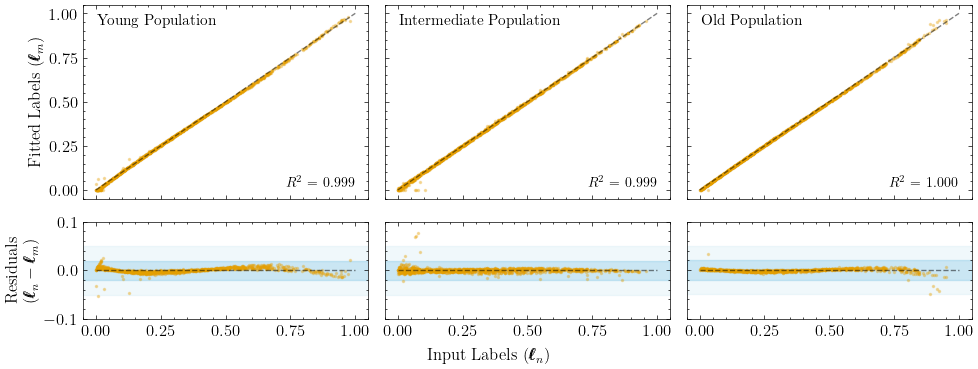

In [165]:
fig, ax = plt.subplots(2, 3, figsize=(10,4), sharey='row', sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Draw widest-to-narrowest so inner bands stay visible and intuitive.
band_specs = [
    (bands5, '#cfe8f3', '5% band', 3),
    (bands2, '#73bfe2', '2% band', 4),
]

for i in range(3):
    y_true = true[:, i]
    y_pred = pred[:, i]

    ax[0, i].plot(y_true, y_pred, 'C0.', markersize=3, alpha=0.3)
    ax[1, i].plot(y_true, res[:, i], 'C0.', markersize=3, alpha=0.3)
    ax[0, i].plot([0,1], [0,1], 'k--', alpha=0.5)
    ax[1, i].plot([0,1], [0,0], 'k--', alpha=0.5)

    for bands, color, _, z in band_specs:
        ax[1, i].axhspan(bands[i][0], bands[i][1], color=color, alpha=0.3)

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    ax[0, i].text(0.95, 0.05, f'$R^2$ = {r2:.3f}', transform=ax[0, i].transAxes, fontsize=10, va='bottom', ha='right')

ax[0,0].set_ylabel(r'Fitted Labels $(\pmb\ell_m)$', fontsize=12)
ax[1,0].set_ylabel('Residuals\n$(\\pmb\\ell_n - \\pmb\\ell_m)$', fontsize=12, multialignment='center')
fig.supxlabel(r'Input Labels $(\pmb\ell_n)$', fontsize=12, y=0.06)

ax[1,0].set_ylim(-0.1, 0.1)
ax[0,0].text(0.05, 0.95, 'Young Population', transform=ax[0,0].transAxes, fontsize=11, fontweight='bold', va='top')
ax[0,1].text(0.05, 0.95, 'Intermediate Population', transform=ax[0,1].transAxes, fontsize=11, fontweight='bold', va='top')
ax[0,2].text(0.05, 0.95, 'Old Population', transform=ax[0,2].transAxes, fontsize=11, fontweight='bold', va='top')

plt.tight_layout()
#plt.savefig('/home/vmehta/honours-project/thesis/figures/3binmodel.pdf', format='pdf')
plt.show()

In [8]:
# Summary statistics per population
population_names = ['Young Population', 'Intermediate Population', 'Old Population']
rows = []

tolerances = [
    ('pct_outside_1pct', 0.01),
    ('pct_outside_2pct', 0.02),
    ('pct_outside_5pct', 0.05),
]

for i, name in enumerate(population_names):
    y_true = true[:, i]
    y_pred = pred[:, i]
    residual = y_true - y_pred

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    center = np.median(residual)
    abs_from_center = np.abs(residual - center)

    row = {
        'population': name,
        'r2': r2,
        'mae': np.mean(np.abs(residual)),
        'rmse': np.sqrt(np.mean(residual ** 2)),
        'bias_mean_residual': np.mean(residual),
        'mad': mad(residual),
    }

    for key, tol in tolerances:
        row[key] = np.mean(abs_from_center > tol) * 100

    rows.append(row)

stats = pd.DataFrame(rows)
stats

,population,r2,mae,rmse,bias_mean_residual,mad,pct_outside_1pct,pct_outside_2pct,pct_outside_5pct
0,Young Population,0.999443,0.003731,0.005484,0.000059,0.002888,4.2,0.7,0.1
1,Intermediate Population,0.999240,0.003156,0.006464,0.000107,0.002331,2.5,0.9,0.4
2,Old Population,0.999723,0.002144,0.003859,-0.000167,0.001487,1.0,0.5,0.0


Residual correlation matrix:


,Young,Intermediate,Old
Young,1.000000,-0.803902,-0.074537
Intermediate,-0.803902,1.000000,-0.533188
Old,-0.074537,-0.533188,1.000000


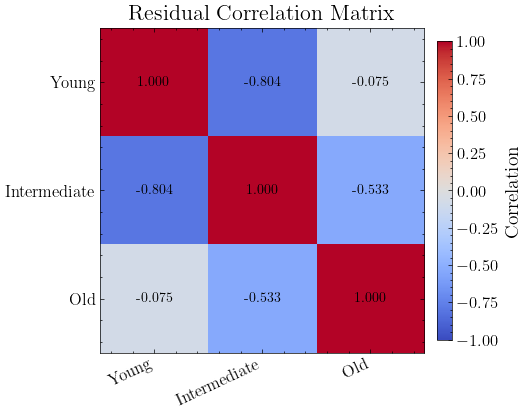

In [151]:
# Correlation matrix for 3-bin residuals
label_names = ['Young', 'Intermediate', 'Old']

# Residuals are defined above as: res = true - pred
corr_res = np.corrcoef(res, rowvar=False)

corr_df = pd.DataFrame(corr_res, index=label_names, columns=label_names)
print('Residual correlation matrix:')
display(corr_df)

fig, ax = plt.subplots(1, 1, figsize=(5.2, 4.4), constrained_layout=True)
im = ax.imshow(corr_res, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(label_names, rotation=25, ha='right')
ax.set_yticklabels(label_names)
ax.set_title('Residual Correlation Matrix')

for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{corr_res[i, j]:.3f}', ha='center', va='center', fontsize=10)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Correlation')

plt.show()

In [5]:
def moving_average(x, w):
        """Returns the moving average of the input array."""
        return np.convolve(x, np.ones(w), 'same') / w

def normalize(v):
    s_flat = v / moving_average(v, 100)
    return s_flat * moving_average(np.ones_like(s_flat), 100)  # dealing with edges

norm_vals = [normalize(v) for v in spec]

In [32]:
true[0]

array([0.46716833, 0.47688115, 0.05595052])

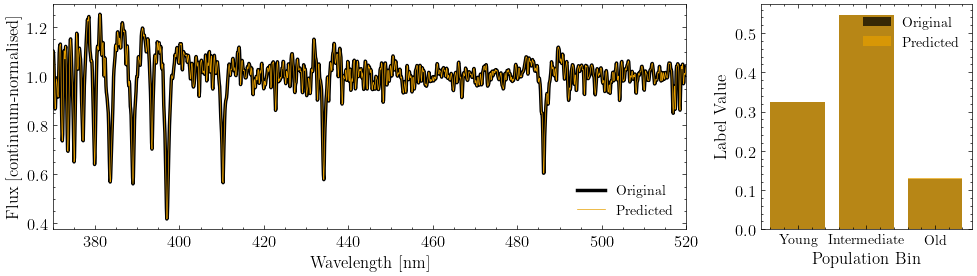

In [148]:
n = 479

fig, ax = plt.subplots(1, 2, figsize=(10,3), sharex='col',gridspec_kw={'width_ratios': [3, 1]})
ax[0].plot(wav/10, true[n] @ norm_vals, 'k', linewidth=2.5, label='Original')
ax[0].plot(wav/10, pred[n] @ norm_vals, 'C0', linewidth=0.5, label='Predicted')
ax[0].legend(fontsize=10, loc='lower right')
ax[0].set_xlabel('Wavelength [nm]', fontsize=12)
ax[0].set_ylabel('Flux [continuum-normalised]', fontsize=12)
ax[0].set_xlim(370, 520)

ax[1].bar(range(len(true[n])), true[n], color='k', alpha=0.7, label='Original')
ax[1].bar(range(len(pred[n])), pred[n], color='C0', alpha=0.7, label='Predicted')
ax[1].legend(fontsize=10)
ax[1].set_xlabel('Population Bin', fontsize=12)
ax[1].set_xticks(range(3))
ax[1].set_xticklabels(['Young', 'Intermediate', 'Old'], fontsize=10)
ax[1].set_ylabel('Label Value', fontsize=12)

plt.tight_layout()
#plt.savefig('/home/vmehta/honours-project/thesis/figures/3binmodel_example.pdf', format='pdf')
plt.show()

## Testing 3 6 and 10 labels with updated model
Log-fluxes vs linear fluxes

In [6]:
lin_pred_6 = np.load('/avatar/vmehta/sfh_1000_6bins_20260406_104404/lognormalbins/snr1000_all_pred.npy')
lin_true_6 = np.load('/avatar/vmehta/sfh_1000_6bins_20260406_104404/lognormalbins/snr1000_all_true.npy')
# log_pred_6 = np.load('/avatar/vmehta/sfh_1000_6bins_20260331_170324/finalmodeltest/log-flux/snr1000_all_pred.npy')
# log_true_6 = np.load('/avatar/vmehta/sfh_1000_6bins_20260331_170324/finalmodeltest/log-flux/snr1000_all_true.npy')

res_lin_6 = lin_pred_6 - lin_true_6
# = log_pred_6 - log_true_6
sixspec = np.load('/home/vmehta/honours-project/code/data/sfh_sixnormalbins_spectra.npy')
six_norm_vals = [normalize(v) for v in sixspec]

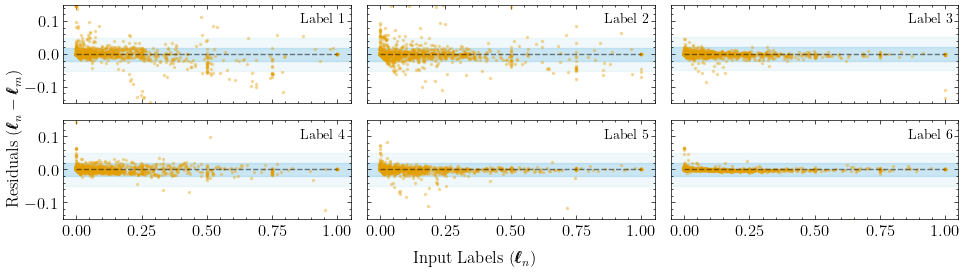

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(10,3), sharex=True, sharey=True)
for i in range(3):
    ax[0, i].plot(lin_true_6[:,i], res_lin_6[:,i], '.', markersize=3, alpha=0.3)
    ax[1, i].plot(lin_true_6[:,3+i], res_lin_6[:,3+i], '.', markersize=3, alpha=0.3)
    ax[0, i].plot([0,1], [0,0], 'k--', alpha=0.5)
    ax[1, i].plot([0,1], [0,0], 'k--', alpha=0.5)
    ax[0, i].text(0.98, 0.9, f'Label {i+1}', transform=ax[0, i].transAxes, fontsize=10, fontweight='bold', va='top', ha='right')
    ax[1, i].text(0.98, 0.9, f'Label {i+4}', transform=ax[1, i].transAxes, fontsize=10, fontweight='bold', va='top', ha='right')

    for bands, color, _, z in band_specs:
        ax[0, i].axhspan(bands[i][0], bands[i][1], color=color, alpha=0.3)
        ax[1, i].axhspan(bands[i][0], bands[i][1], color=color, alpha=0.3)


ax[0,0].set_ylim(-0.15, 0.15)
fig.supxlabel(r'Input Labels $(\pmb\ell_n)$', fontsize=12, y=0.07)
fig.supylabel('Residuals $(\\pmb\\ell_n - \\pmb\\ell_m)$', fontsize=12, x=0.03)

plt.tight_layout()
#plt.savefig('/home/vmehta/honours-project/thesis/figures/6binresiduals.pdf', format='pdf')
plt.show()

In [43]:
# Threshold statistics for 6-label residuals using the defined median-centered bands
threshold_rows = []

for i in range(6):
    r = res_lin_6[:, i]
    b1_lo, b1_hi = bands1[i]
    b2_lo, b2_hi = bands2[i]
    b5_lo, b5_hi = bands5[i]

    pct_outside_1 = np.mean((r < b1_lo) | (r > b1_hi)) * 100
    pct_outside_2 = np.mean((r < b2_lo) | (r > b2_hi)) * 100
    pct_outside_5 = np.mean((r < b5_lo) | (r > b5_hi)) * 100

    threshold_rows.append({
        'label': f'Label {i+1}',
        'pct_outside_1pct_band': pct_outside_1,
        'pct_outside_2pct_band': pct_outside_2,
        'pct_outside_5pct_band': pct_outside_5,
    })

threshold_stats_6 = pd.DataFrame(threshold_rows)
threshold_stats_6

,label,pct_outside_1pct_band,pct_outside_2pct_band,pct_outside_5pct_band
0,Label 1,41.5,20.0,8.8
1,Label 2,45.0,22.2,7.9
2,Label 3,18.0,4.4,1.7
3,Label 4,28.0,5.9,1.1
4,Label 5,21.3,5.1,1.9
5,Label 6,3.3,1.4,0.9


6-bin residual correlation matrix:


,L1,L2,L3,L4,L5,L6
L1,1.000000,-0.950404,0.087111,-0.028726,0.227182,-0.104128
L2,-0.950404,1.000000,-0.215724,0.116721,-0.306986,0.163729
L3,0.087111,-0.215724,1.000000,-0.308729,-0.012647,-0.147715
L4,-0.028726,0.116721,-0.308729,1.000000,-0.303415,0.093536
L5,0.227182,-0.306986,-0.012647,-0.303415,1.000000,-0.270222
L6,-0.104128,0.163729,-0.147715,0.093536,-0.270222,1.000000


6-bin residual covariance matrix:


,L1,L2,L3,L4,L5,L6
L1,0.004979,-0.004517,0.000168,-0.000033,0.000358,-0.000115
L2,-0.004517,0.004537,-0.000398,0.000129,-0.000462,0.000173
L3,0.000168,-0.000398,0.000749,-0.000138,-0.000008,-0.000063
L4,-0.000033,0.000129,-0.000138,0.000268,-0.000111,0.000024
L5,0.000358,-0.000462,-0.000008,-0.000111,0.000500,-0.000095
L6,-0.000115,0.000173,-0.000063,0.000024,-0.000095,0.000247


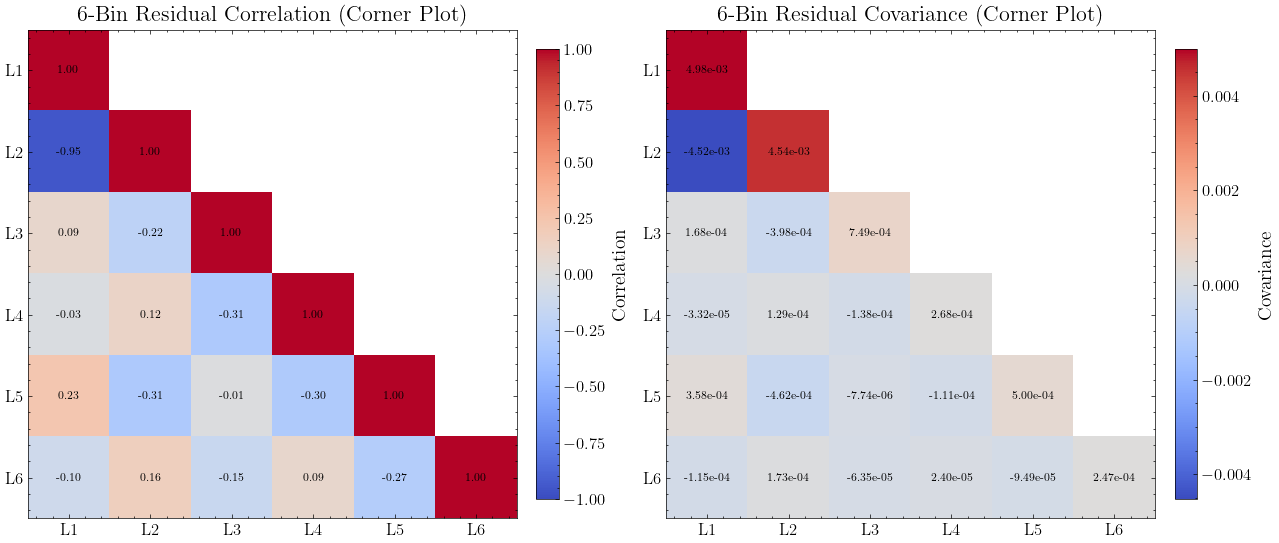

In [156]:
# Correlation + covariance matrices for 6-bin residuals (corner-style)
label_names_6 = [f'L{i+1}' for i in range(6)]

# Residuals for 6-bin model are defined above as: res_lin_6 = lin_pred_6 - lin_true_6
corr_res_6 = np.corrcoef(res_lin_6, rowvar=False)
cov_res_6 = np.cov(res_lin_6, rowvar=False)

corr_df_6 = pd.DataFrame(corr_res_6, index=label_names_6, columns=label_names_6)
cov_df_6 = pd.DataFrame(cov_res_6, index=label_names_6, columns=label_names_6)
print('6-bin residual correlation matrix:')
display(corr_df_6)
print('6-bin residual covariance matrix:')
display(cov_df_6)

# Keep only lower triangle (including diagonal) to avoid duplicate mirrored entries
mask_upper = np.triu(np.ones_like(corr_res_6, dtype=bool), k=1)
corr_corner = np.ma.array(corr_res_6, mask=mask_upper)
cov_corner = np.ma.array(cov_res_6, mask=mask_upper)

fig, ax = plt.subplots(1, 2, figsize=(12.8, 5.6), constrained_layout=True)

im0 = ax[0].imshow(corr_corner, cmap='coolwarm', vmin=-1, vmax=1)
ax[0].set_xticks(range(6))
ax[0].set_yticks(range(6))
ax[0].set_xticklabels(label_names_6)
ax[0].set_yticklabels(label_names_6)
ax[0].set_title('6-Bin Residual Correlation (Corner Plot)')
for i in range(6):
    for j in range(i + 1):
        ax[0].text(j, i, f'{corr_res_6[i, j]:.2f}', ha='center', va='center', fontsize=8)
cbar0 = fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
cbar0.set_label('Correlation')

im1 = ax[1].imshow(cov_corner, cmap='coolwarm')
ax[1].set_xticks(range(6))
ax[1].set_yticks(range(6))
ax[1].set_xticklabels(label_names_6)
ax[1].set_yticklabels(label_names_6)
ax[1].set_title('6-Bin Residual Covariance (Corner Plot)')
for i in range(6):
    for j in range(i + 1):
        ax[1].text(j, i, f'{cov_res_6[i, j]:.2e}', ha='center', va='center', fontsize=8)
cbar1 = fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
cbar1.set_label('Covariance')

plt.show()

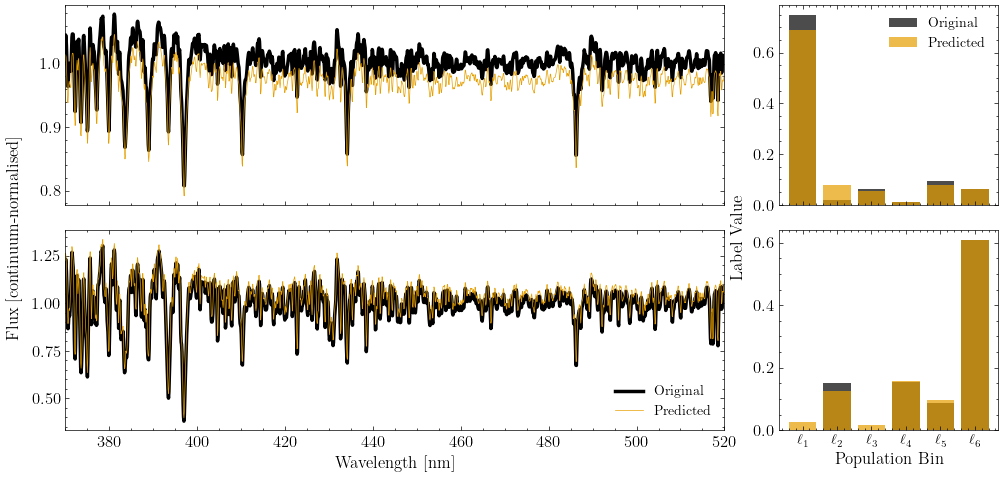

In [ ]:
n = 3
m = 675

fig, ax = plt.subplots(2, 2, figsize=(10,5), sharex='col',gridspec_kw={'width_ratios': [3, 1]})

ax[0,0].plot(wav/10, lin_true_6[n] @ six_norm_vals, 'k', linewidth=2.5, label='Original')
ax[0,0].plot(wav/10, lin_pred_6[n] @ six_norm_vals, 'C0', linewidth=0.5, label='Predicted')

ax[1,0].plot(wav/10, lin_true_6[m] @ six_norm_vals, 'k', linewidth=2.5, label='Original')
ax[1,0].plot(wav/10, lin_pred_6[m] @ six_norm_vals, 'C0', linewidth=0.5, label='Predicted')
ax[1,0].set_xlabel('Wavelength [nm]', fontsize=12)
ax[1,0].set_xlim(370, 520)
ax[1,0].legend(fontsize=10, loc='lower right')

ax[0,1].bar(range(len(lin_true_6[n])), lin_true_6[n], color='k', alpha=0.7, label='Original')
ax[0,1].bar(range(len(lin_pred_6[n])), lin_pred_6[n], color='C0', alpha=0.7, label='Predicted')
ax[0,1].legend(fontsize=10)

ax[1,1].bar(range(len(lin_true_6[m])), lin_true_6[m], color='k', alpha=0.7, label='Original')
ax[1,1].bar(range(len(lin_pred_6[m])), lin_pred_6[m], color='C0', alpha=0.7, label='Predicted')
ax[1,1].set_xlabel('Population Bin', fontsize=12)
ax[1,1].set_xticks(range(6))
ax[1,1].set_xticklabels([f'$\\ell_{{{i}}}$' for i in range(1, 7)], fontsize=10)
ax[1,1].set_ylabel('', fontsize=12)

fig.text(-0.01, 0.5, 'Flux [continuum-normalised]', va='center', rotation='vertical', fontsize=12)
fig.text(0.715, 0.5, 'Label Value', va='center', rotation='vertical', fontsize=12)

plt.tight_layout()
#plt.savefig('/home/vmehta/honours-project/thesis/figures/6binmodel_example.pdf', format='pdf')
plt.show()

## 10-label plots

In [9]:
f10 = '/avatar/vmehta/sfh_1000_10bins_20260406_125356/lognormalbins'
pred10 = np.load(f'{f10}/snr1000_all_pred.npy')
true10 = np.load(f'{f10}/snr1000_all_true.npy')
res10 = pred10 - true10
spec10 = np.load('/home/vmehta/honours-project/code/data/sfh_tennormalbins_spectra.npy')

ten_norm_vals = [normalize(v) for v in spec10]

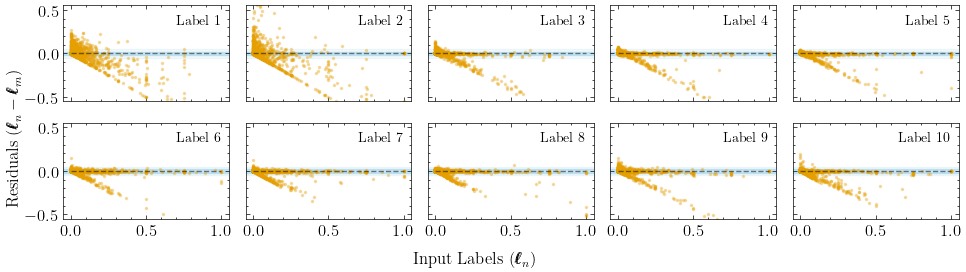

In [175]:
fig, ax = plt.subplots(2, 5, figsize=(10,3), sharex=True, sharey=True)
for i in range(5):
    ax[0, i].plot(true10[:,i], res10[:,i], '.', markersize=3, alpha=0.3)
    ax[1, i].plot(true10[:,5+i], res10[:,5+i], '.', markersize=3, alpha=0.3)
    ax[0, i].plot([0,1], [0,0], 'k--', alpha=0.5)
    ax[1, i].plot([0,1], [0,0], 'k--', alpha=0.5)
    ax[0, i].text(0.95, 0.9, f'Label {i+1}', transform=ax[0, i].transAxes, fontsize=10, fontweight='bold', va='top', ha='right')
    ax[1, i].text(0.95, 0.9, f'Label {i+6}', transform=ax[1, i].transAxes, fontsize=10, fontweight='bold', va='top', ha='right')

    for bands, color, _, z in band_specs:
        ax[0, i].axhspan(bands[i][0], bands[i][1], color=color, alpha=0.3)
        ax[1, i].axhspan(bands[i][0], bands[i][1], color=color, alpha=0.3)

ax[0,0].set_ylim(-0.55, 0.55)

fig.supxlabel(r'Input Labels $(\pmb\ell_n)$', fontsize=12, y=0.07)
fig.supylabel('Residuals $(\\pmb\\ell_n - \\pmb\\ell_m)$', fontsize=12, x=0.03)

plt.tight_layout()
plt.savefig('/home/vmehta/honours-project/thesis/figures/10binresiduals.pdf', format='pdf')
plt.show()

In [171]:
# Tolerance statistics for 10-label residuals
# Uses median-centered bands per label, analogous to the 3/6-label stats.
threshold_rows_10 = []

for i in range(10):
    r = res10[:, i]
    center = np.median(r)

    b1_lo, b1_hi = center - 0.01, center + 0.01
    b2_lo, b2_hi = center - 0.02, center + 0.02
    b5_lo, b5_hi = center - 0.05, center + 0.05

    pct_outside_1 = np.mean((r < b1_lo) | (r > b1_hi)) * 100
    pct_outside_2 = np.mean((r < b2_lo) | (r > b2_hi)) * 100
    pct_outside_5 = np.mean((r < b5_lo) | (r > b5_hi)) * 100

    threshold_rows_10.append({
        'label': f'Label {i+1}',
        'median_residual': center,
        'pct_outside_1pct_band': pct_outside_1,
        'pct_outside_2pct_band': pct_outside_2,
        'pct_outside_5pct_band': pct_outside_5,
    })

threshold_stats_10 = pd.DataFrame(threshold_rows_10)
threshold_stats_10

,label,median_residual,pct_outside_1pct_band,pct_outside_2pct_band,pct_outside_5pct_band
0,Label 1,-6.318240e-04,74.4,62.2,45.5
1,Label 2,-6.708356e-04,73.4,61.9,42.5
2,Label 3,3.469447e-18,41.0,29.0,16.5
3,Label 4,0.000000e+00,37.6,26.3,11.9
4,Label 5,-8.700128e-05,39.8,20.7,9.0
5,Label 6,-2.218869e-04,49.0,24.5,9.2
6,Label 7,-1.221176e-03,42.4,24.2,12.8
7,Label 8,-5.124276e-04,39.9,21.7,10.4
8,Label 9,-1.122367e-04,52.0,31.6,11.3
9,Label 10,-1.285689e-03,39.4,23.4,14.1


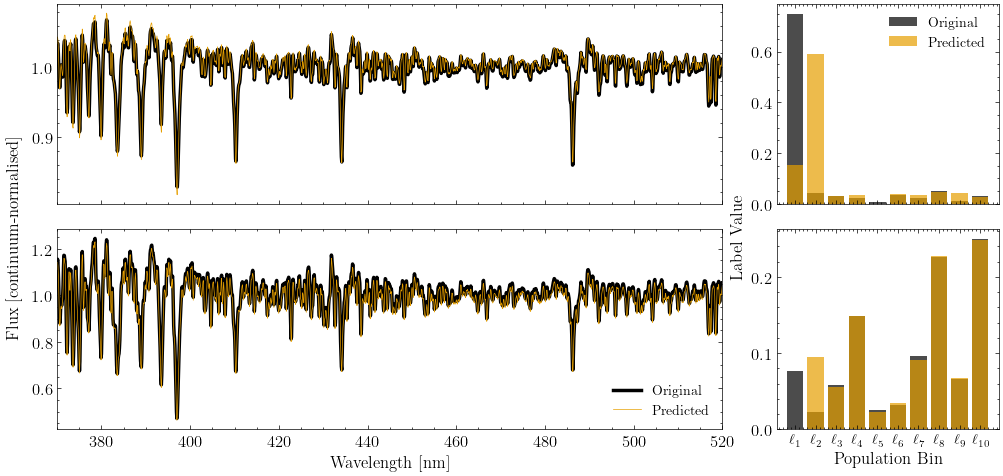

In [77]:
n = 153
m = 996

fig, ax = plt.subplots(2, 2, figsize=(10,5), sharex='col',gridspec_kw={'width_ratios': [3, 1]})

ax[0,0].plot(wav/10, true10[n] @ ten_norm_vals, 'k', linewidth=2.5, label='Original')
ax[0,0].plot(wav/10, pred10[n] @ ten_norm_vals, 'C0', linewidth=0.5, label='Predicted')

ax[1,0].plot(wav/10, true10[m] @ ten_norm_vals, 'k', linewidth=2.5, label='Original')
ax[1,0].plot(wav/10, pred10[m] @ ten_norm_vals, 'C0', linewidth=0.5, label='Predicted')
ax[1,0].set_xlabel('Wavelength [nm]', fontsize=12)
ax[1,0].set_xlim(370, 520)
ax[1,0].legend(fontsize=10, loc='lower right')

ax[0,1].bar(range(len(true10[n])), true10[n], color='k', alpha=0.7, label='Original')
ax[0,1].bar(range(len(pred10[n])), pred10[n], color='C0', alpha=0.7, label='Predicted')
ax[0,1].legend(fontsize=10)

ax[1,1].bar(range(len(true10[m])), true10[m], color='k', alpha=0.7, label='Original')
ax[1,1].bar(range(len(pred10[m])), pred10[m], color='C0', alpha=0.7, label='Predicted')
ax[1,1].set_xlabel('Population Bin', fontsize=12)
ax[1,1].set_xticks(range(10))
ax[1,1].set_xticklabels([f'$\\ell_1$', f'$\\ell_2$', f'$\\ell_3$', f'$\\ell_4$', f'$\\ell_5$', f'$\\ell_6$', f'$\\ell_7$', f'$\\ell_8$', f'$\\ell_9$', f'$\\ell_{{10}}$'], fontsize=10)
ax[1,1].set_ylabel('', fontsize=12)

fig.text(-0.01, 0.5, 'Flux [continuum-normalised]', va='center', rotation='vertical', fontsize=12)
fig.text(0.715, 0.5, 'Label Value', va='center', rotation='vertical', fontsize=12)

plt.tight_layout()
plt.savefig('/home/vmehta/honours-project/thesis/figures/10binmodel_example.pdf', format='pdf')
plt.show()

10-label residual correlation matrix:


,L1,L2,L3,L4,L5,L6,L7,L8,L9,L10
L1,1.000000,-0.725044,-0.110173,-0.114835,0.032799,-0.049085,0.062677,0.013029,-0.068908,-0.065974
L2,-0.725044,1.000000,-0.134896,-0.012206,0.023561,0.169731,0.167743,0.153486,0.199034,0.215688
L3,-0.110173,-0.134896,1.000000,-0.072483,0.052898,0.060768,0.123586,0.048642,0.012362,0.097063
L4,-0.114835,-0.012206,-0.072483,1.000000,0.012201,0.096637,0.103707,0.038937,0.061803,0.118850
L5,0.032799,0.023561,0.052898,0.012201,1.000000,-0.036806,0.058623,0.075959,0.067534,0.191882
L6,-0.049085,0.169731,0.060768,0.096637,-0.036806,1.000000,0.100029,0.077296,0.057038,0.354629
L7,0.062677,0.167743,0.123586,0.103707,0.058623,0.100029,1.000000,0.035915,0.235423,0.290755
L8,0.013029,0.153486,0.048642,0.038937,0.075959,0.077296,0.035915,1.000000,0.017211,0.138455
L9,-0.068908,0.199034,0.012362,0.061803,0.067534,0.057038,0.235423,0.017211,1.000000,-0.223635
L10,-0.065974,0.215688,0.097063,0.118850,0.191882,0.354629,0.290755,0.138455,-0.223635,1.000000


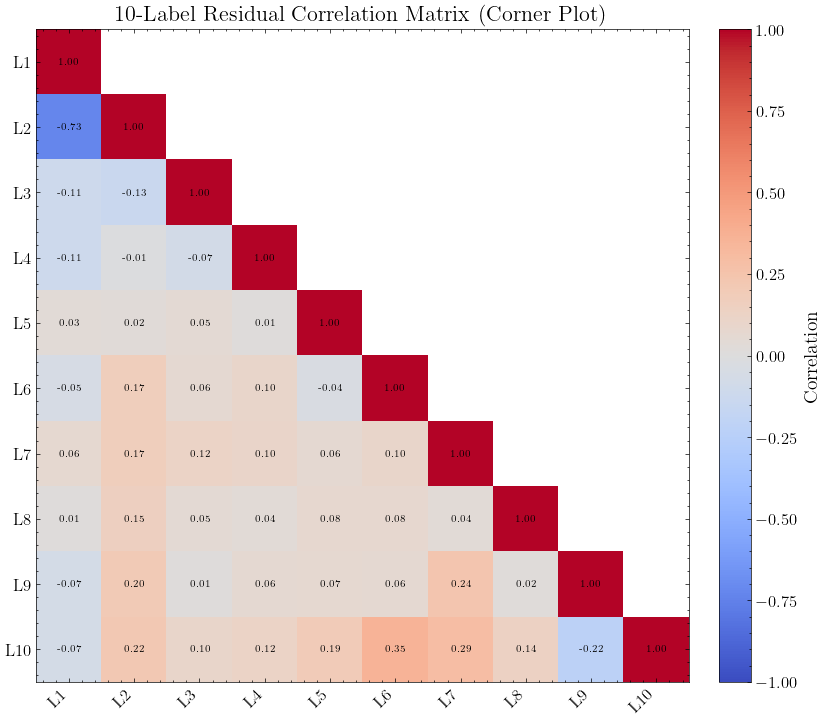

In [78]:
# Correlation matrix for 10-label residuals (corner-style)
label_names_10 = [f'L{i+1}' for i in range(10)]

# Residuals for 10-label model are defined above as: res10 = pred10 - true10
corr_res_10 = np.corrcoef(res10, rowvar=False)

corr_df_10 = pd.DataFrame(corr_res_10, index=label_names_10, columns=label_names_10)
print('10-label residual correlation matrix:')
display(corr_df_10)

# Keep only lower triangle (including diagonal) to avoid duplicate mirrored entries
mask_upper = np.triu(np.ones_like(corr_res_10, dtype=bool), k=1)
corr_corner_10 = np.ma.array(corr_res_10, mask=mask_upper)

fig, ax = plt.subplots(1, 1, figsize=(8.8, 7.2), constrained_layout=True)
im = ax.imshow(corr_corner_10, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(label_names_10, rotation=45, ha='right')
ax.set_yticklabels(label_names_10)
ax.set_title('10-Label Residual Correlation Matrix (Corner Plot)')

for i in range(10):
    for j in range(i + 1):
        ax.text(j, i, f'{corr_res_10[i, j]:.2f}', ha='center', va='center', fontsize=7)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Correlation')

plt.show()